Sample Data:
    Soil_Nitrogen    Rainfall      Yield  Water_Usage
0      65.181508  530.055841  10.914471   253.067627
1      84.722306  804.571420  17.349682   436.541662
2      87.412379  718.196795  15.444450   341.237799
3      77.724900  601.043943  12.390223   265.167674
4      91.015464  720.790624  14.949099   367.322549

Cluster Centers:
    Soil_Nitrogen    Rainfall      Yield  Water_Usage
0      58.111029  469.872427  10.051300   231.402183
1      84.940930  687.797200  14.658722   345.341034

--- Evaluation Metrics ---
Inertia (WCSS): 67.08368239326083
Silhouette Score: 0.541873436339785
Davies-Bouldin Index: 0.645021861227679


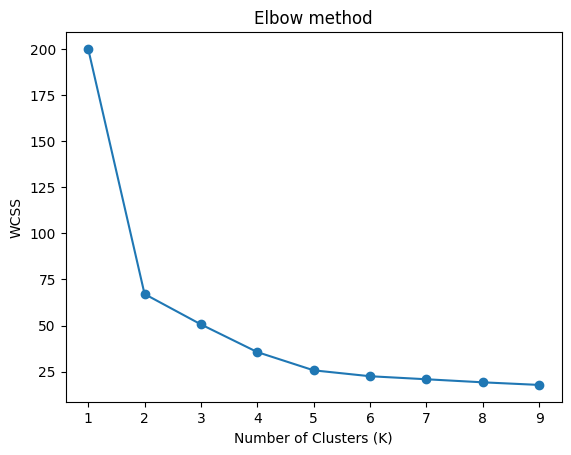

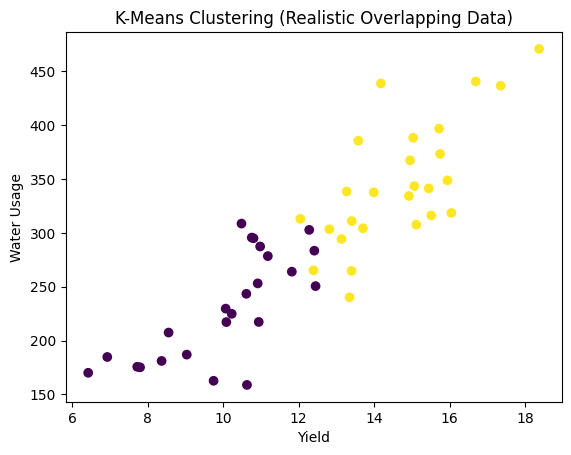

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler


np.random.seed(42)
n_samples = 50

# Cluster 1: Low yield, low water usage (but overlapping)
cluster1 = pd.DataFrame({
    'Soil_Nitrogen': np.random.normal(60, 8, n_samples//2),
    'Rainfall': np.random.normal(500, 80, n_samples//2),
})

cluster1['Yield'] = 0.02 * cluster1['Rainfall'] + 0.01 * cluster1['Soil_Nitrogen'] + np.random.normal(0, 0.5, n_samples//2)
cluster1['Water_Usage'] = 0.5 * cluster1['Rainfall'] + np.random.normal(0, 40, n_samples//2)

# Cluster 2: High yield, high water usage (but overlapping)
cluster2 = pd.DataFrame({
    'Soil_Nitrogen': np.random.normal(85, 8, n_samples//2),
    'Rainfall': np.random.normal(700, 80, n_samples//2),
})

cluster2['Yield'] = 0.02 * cluster2['Rainfall'] + 0.01 * cluster2['Soil_Nitrogen'] + np.random.normal(0, 0.5, n_samples//2)
cluster2['Water_Usage'] = 0.5 * cluster2['Rainfall'] + np.random.normal(0, 40, n_samples//2)

# Combine and shuffle
data = pd.concat([cluster1, cluster2]).sample(frac=1).reset_index(drop=True)

print("Sample Data:\n", data.head())

# -------------------------------
# 2. Preprocessing (Scaling)
# -------------------------------
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# -------------------------------
# 3. Apply K-Means
# -------------------------------
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(scaled_data)

labels = kmeans.labels_
data['Cluster'] = labels

# -------------------------------
# 4. Cluster Centers
# -------------------------------
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=data.columns[:-1])

print("\nCluster Centers:\n", centroids_df)

# -------------------------------
# 5. Evaluation Metrics
# -------------------------------
print("\n--- Evaluation Metrics ---")

# (a) Inertia (WCSS)
print("Inertia (WCSS):", kmeans.inertia_)

# (b) Silhouette Score
sil_score = silhouette_score(scaled_data, labels)
print("Silhouette Score:", sil_score)

# (c) Davies-Bouldin Index
db_index = davies_bouldin_score(scaled_data, labels)
print("Davies-Bouldin Index:", db_index)

# -------------------------------
# 6. Elbow Method
# -------------------------------
wcss = []
K_range = range(1, 10)

for k_val in K_range:
    km = KMeans(n_clusters=k_val, random_state=42)
    km.fit(scaled_data)
    wcss.append(km.inertia_)

plt.figure()
plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow method")
plt.show()

# -------------------------------
# 7. Visualization (Overlapping Clusters)
# -------------------------------
plt.figure()
plt.scatter(data['Yield'], data['Water_Usage'], c=labels)
plt.xlabel("Yield")
plt.ylabel("Water Usage")
plt.title("K-Means Clustering (Realistic Overlapping Data)")
plt.show()